In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
# from standard_e2e import Modality
from standard_e2e.enums import Modality

TRAIN_DIR     = '../data/processed/waymo_e2e/training/'
MANIFEST_PATH = '../data/train_manifest.json'
FEATURES_DIR  = '../data/processed/waymo_e2e/features/'
os.makedirs(FEATURES_DIR, exist_ok=True)

with open(MANIFEST_PATH, 'r') as f:
    manifest = json.load(f)

CLASSES = ['straight', 'left-turn', 'right-turn', 'lane-change-left', 'lane-change-right']
print(f'Loaded {len(manifest)} sequences')
print(Counter(v['label'] for v in manifest.values()))

Loaded 2037 sequences
Counter({'straight': 745, 'right-turn': 467, 'left-turn': 392, 'lane-change-right': 222, 'lane-change-left': 200, 'stationary': 11})


## Load pre-extracted features

If you downloaded the feature arrays from Google Drive, run the cell below and skip
the extraction loop further down. If you're re-running extraction from scratch, skip
this cell and run the extraction loop instead.

In [3]:

_arrays_exist = all(
    os.path.exists(os.path.join(FEATURES_DIR, f))
    for f in ['features_hog.npy', 'features_yolo.npy', 'features_road.npy', 'labels.npy']
)

if _arrays_exist:
    hog_features  = np.load(os.path.join(FEATURES_DIR, 'features_hog.npy'))
    yolo_features = np.load(os.path.join(FEATURES_DIR, 'features_yolo.npy'))
    road_features = np.load(os.path.join(FEATURES_DIR, 'features_road.npy'))
    labels        = np.load(os.path.join(FEATURES_DIR, 'labels.npy'), allow_pickle=True)
    print('Loaded features:')
    print(f'  HOG:   {hog_features.shape}')
    print(f'  YOLO:  {yolo_features.shape}')
    print(f'  Road:  {road_features.shape}')
    print(f'  Labels: {Counter(labels)}')
    print('\nArrays loaded -- skip the extraction loop below.')
else:
    print('Feature arrays not found -- run the extraction loop below, then re-run this cell.')

Feature arrays not found -- run the extraction loop below, then re-run this cell.


Image shape: (142, 384, 3)


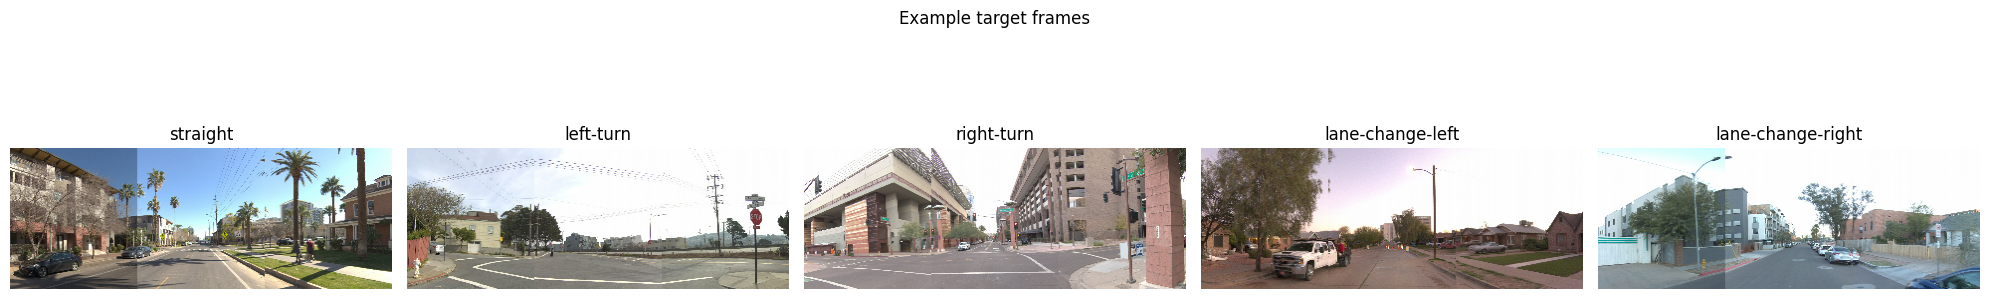

In [4]:
examples = {}  # label -> image (H, W, 3) uint8
for seq_id, entry in manifest.items():
    label = entry['label']
    if label in CLASSES and label not in examples:
        data = np.load(os.path.join(TRAIN_DIR, entry['target_fname']), allow_pickle=True)
        img = np.array(data['_modality_data'].item()[Modality.CAMERAS])
        examples[label] = img
    if len(examples) == len(CLASSES):
        break

print(f'Image shape: {examples["straight"].shape}')

fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))
for i, cls in enumerate(CLASSES):
    axes[i].imshow(examples[cls])
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Example target frames')
plt.tight_layout()
plt.show()

## Simple Feature 1: HOG
Histogram of Oriented Gradients — captures edge structure, lane markings, road geometry.

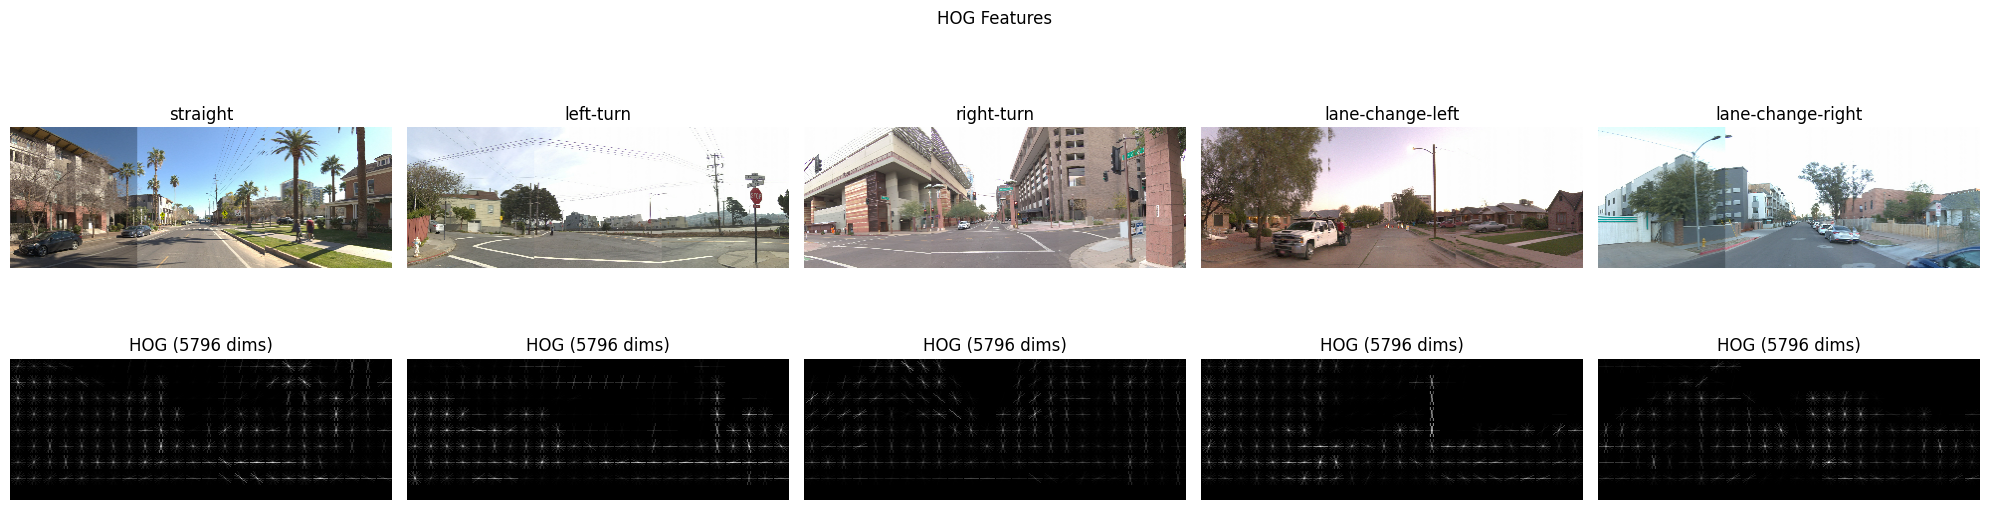

HOG feature vector length: 5796


In [5]:
from skimage.feature import hog
from skimage import color

HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (16, 16),
    'cells_per_block': (2, 2),
    'channel_axis': -1,
}

def extract_hog(img):
    features, hog_img = hog(img, visualize=True, **HOG_PARAMS)
    return features, hog_img

# visualize HOG for each class
fig, axes = plt.subplots(2, len(CLASSES), figsize=(20, 6))
for i, cls in enumerate(CLASSES):
    features, hog_img = extract_hog(examples[cls])
    axes[0, i].imshow(examples[cls])
    axes[0, i].set_title(cls)
    axes[0, i].axis('off')
    axes[1, i].imshow(hog_img, cmap='gray')
    axes[1, i].set_title(f'HOG ({len(features)} dims)')
    axes[1, i].axis('off')
plt.suptitle('HOG Features')
plt.tight_layout()
plt.show()

# confirm feature dimension
sample_features, _ = extract_hog(examples['straight'])
print(f'HOG feature vector length: {len(sample_features)}')

## Simple Feature 2: HSV Histogram
Color distribution in HSV space — captures scene type, lighting, road surface appearance.

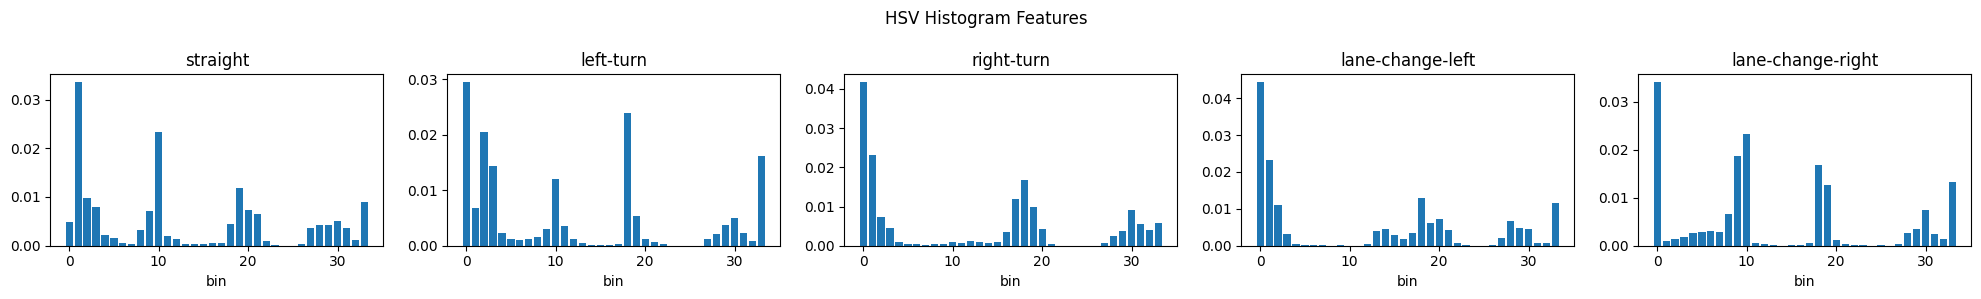

HSV feature vector length: 34


In [6]:
import cv2

HSV_BINS = (18, 8, 8)  # hue, saturation, value bins

def extract_hsv_histogram(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hist_h = np.histogram(hsv[:, :, 0], bins=HSV_BINS[0], range=(0, 180), density=True)[0]
    hist_s = np.histogram(hsv[:, :, 1], bins=HSV_BINS[1], range=(0, 256), density=True)[0]
    hist_v = np.histogram(hsv[:, :, 2], bins=HSV_BINS[2], range=(0, 256), density=True)[0]
    return np.concatenate([hist_h, hist_s, hist_v])

# visualize HSV histograms per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 3))
for i, cls in enumerate(CLASSES):
    features = extract_hsv_histogram(examples[cls])
    axes[i].bar(range(len(features)), features)
    axes[i].set_title(cls)
    axes[i].set_xlabel('bin')
plt.suptitle('HSV Histogram Features')
plt.tight_layout()
plt.show()

print(f'HSV feature vector length: {len(extract_hsv_histogram(examples["straight"]))}')

## Complex Feature: YOLO Detections
Object detection via YOLOv8 — presence and count of road-relevant objects (cars, pedestrians, traffic lights, stop signs, etc.).

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Matt\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


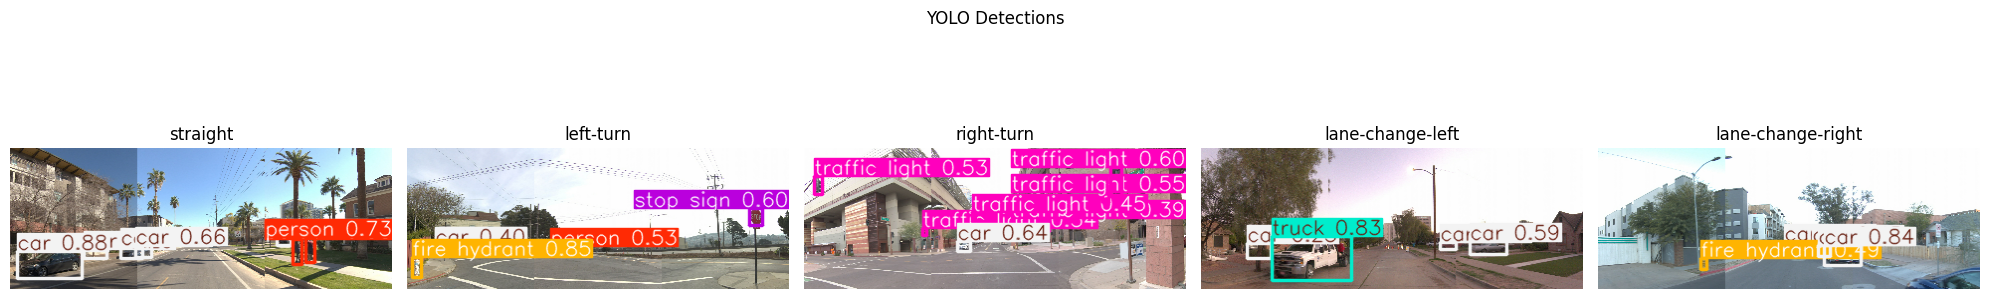

YOLO feature vector length: 8
Classes: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'traffic light', 'stop sign']

straight: [          2     0.76906     0.73244   0.0039128           0           0           0           0           5     0.34275     0.74599   0.0093639           0           0           0           0           0           0           0           0           0           0           0           0           0           0
           0           0           0           0           0           0]
left-turn: [          1     0.38075     0.73787  0.00078114           0           0           0           0           2    0.083438     0.72675   0.0014633           0           0           0           0           0           0           0           0           0           0           0           0           0           0
           0           0           1     0.91412     0.49349   0.0038026]
right-turn: [          0           0           0           0           0    

In [9]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8s.pt')  #

# COCO classes relevant to driving
DRIVING_CLASSES = {
    0: 'person',
    1: 'bicycle',
    2: 'car',
    3: 'motorcycle',
    5: 'bus',
    7: 'truck',
    9: 'traffic light',
    11: 'stop sign',
}

def extract_yolo_features(img, model, driving_classes=DRIVING_CLASSES):
    """
    Returns a feature vector encoding count, mean normalized x position,
    mean normalized y position, and mean relative size for each driving-relevant class.
    Feature vector length = len(driving_classes) * 4
    Order: [count, mean_x, mean_y, mean_size] per class, sorted by class id
    """
    H, W = img.shape[:2]
    results = model(img, verbose=False)
    
    # accumulate detections per class
    class_detections = defaultdict(list)
    for box in results[0].boxes:
        cls_id = int(box.cls)
        if cls_id in driving_classes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cx = ((x1 + x2) / 2) / W       # normalized center x
            cy = ((y1 + y2) / 2) / H       # normalized center y
            size = ((x2 - x1) * (y2 - y1)) / (W * H)  # relative area
            class_detections[cls_id].append((cx, cy, size))
    
    # build feature vector
    features = []
    for cls_id in sorted(driving_classes.keys()):
        dets = class_detections[cls_id]
        if len(dets) == 0:
            features.extend([0, 0, 0, 0])  # count, mean_x, mean_y, mean_size
        else:
            count = len(dets)
            mean_x = np.mean([d[0] for d in dets])
            mean_y = np.mean([d[1] for d in dets])
            mean_size = np.mean([d[2] for d in dets])
            features.extend([count, mean_x, mean_y, mean_size])
    
    return np.array(features, dtype=np.float32)

# visualize YOLO detections on examples
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))
for i, cls in enumerate(CLASSES):
    results = yolo_model(examples[cls], verbose=False)
    annotated = results[0].plot()
    axes[i].imshow(annotated)
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('YOLO Detections')
plt.tight_layout()
plt.show()

# print feature vectors for each class
print(f'YOLO feature vector length: {len(DRIVING_CLASSES)}')
print(f'Classes: {[DRIVING_CLASSES[k] for k in sorted(DRIVING_CLASSES.keys())]}')
print()
for cls in CLASSES:
    features = extract_yolo_features(examples[cls], yolo_model)
    print(f'{cls}: {features}')

## Edge detection + Hough lines

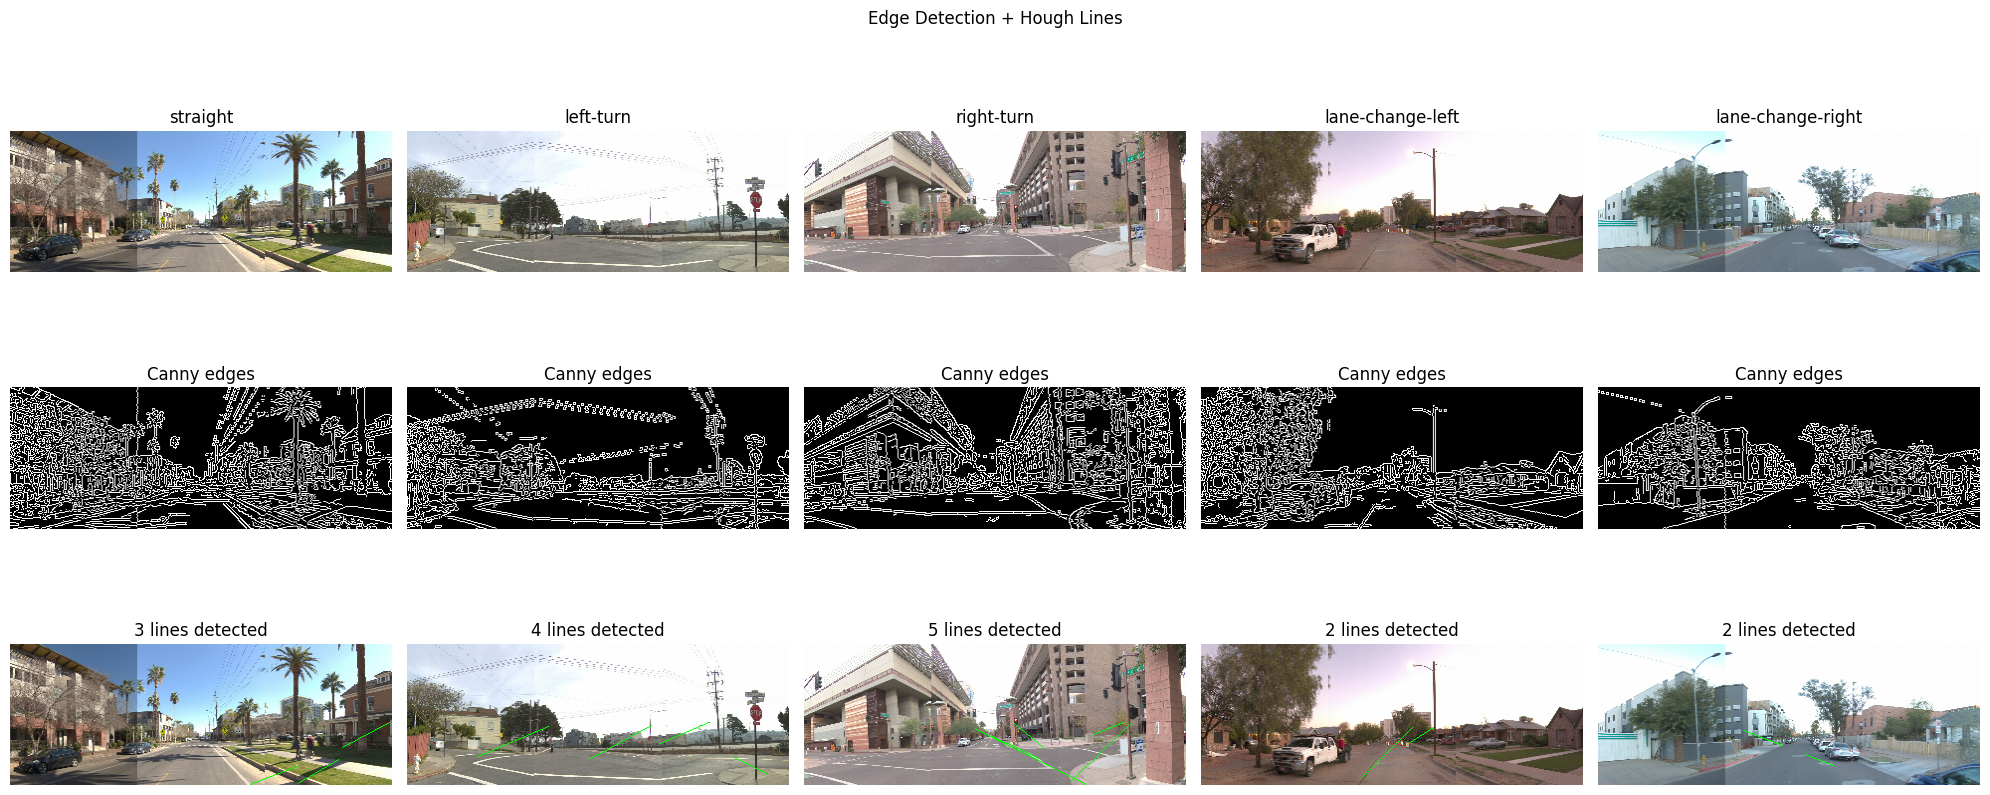

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_edges_and_lines(img, 
                            canny_low=30, 
                            canny_high=100,
                            hough_threshold=15,
                            min_line_length=20,
                            max_line_gap=15,
                            road_region_frac=0.55):
    """
    Step 1: Edge detection and Hough line extraction.
    
    Filters lines to the lower road_region_frac of the image
    to focus on road geometry and ignore sky/buildings.
    
    Returns:
        edges: Canny edge map
        lines: array of detected line segments (x1, y1, x2, y2)
        road_mask: binary mask of the road region
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    
    # focus on lower portion of image (road region)
    road_y_start = int(H * road_region_frac)
    road_mask = np.zeros_like(gray)
    road_mask[road_y_start:, :] = 1
    
    # Canny edge detection
    edges = cv2.Canny(gray, canny_low, canny_high)
    edges_masked = edges * road_mask
    
    # Hough line detection
    lines_raw = cv2.HoughLinesP(
        edges_masked,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )
    
    lines = []
    if lines_raw is not None:
        for line in lines_raw:
            x1, y1, x2, y2 = line[0]
            # filter near-horizontal lines (likely not lane markings)
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if 20 < angle < 75 or 105 < angle < 160:
                lines.append((x1, y1, x2, y2))
    
    return edges, np.array(lines), road_mask

# visualize on example images
fig, axes = plt.subplots(3, len(CLASSES), figsize=(20, 9))

for i, cls in enumerate(CLASSES):
    img = examples[cls]
    H, W = img.shape[:2]
    edges, lines, road_mask = detect_edges_and_lines(img)
    
    # original image
    axes[0, i].imshow(img)
    axes[0, i].set_title(cls)
    axes[0, i].axis('off')
    
    # edge map
    axes[1, i].imshow(edges, cmap='gray')
    axes[1, i].set_title(f'Canny edges')
    axes[1, i].axis('off')
    
    # image with detected lines overlaid
    img_lines = img.copy()
    for x1, y1, x2, y2 in lines:
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 1)
    axes[2, i].imshow(img_lines)
    axes[2, i].set_title(f'{len(lines)} lines detected')
    axes[2, i].axis('off')

plt.suptitle('Edge Detection + Hough Lines')
plt.tight_layout()
plt.savefig('hough_lines.png', dpi=150)
plt.show()

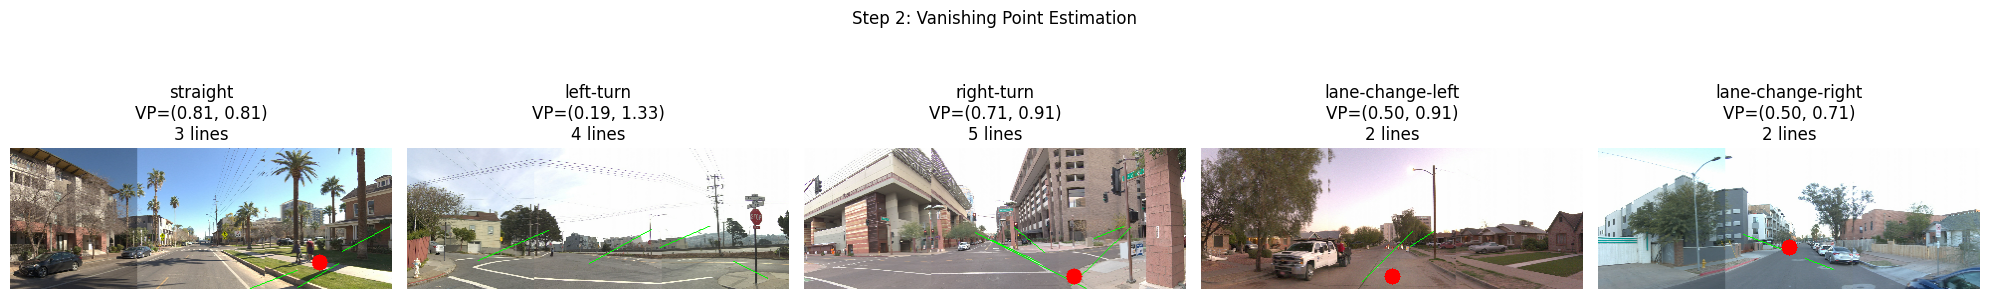

Normalized vanishing points (x=0 left, x=1 right, y=0 top, y=1 bottom):
  straight: x=0.810, y=0.810 (3 lines)
  left-turn: x=0.190, y=1.328 (4 lines)
  right-turn: x=0.707, y=0.914 (5 lines)
  lane-change-left: x=0.500, y=0.914 (2 lines)
  lane-change-right: x=0.500, y=0.707 (2 lines)


In [11]:
def estimate_vanishing_point(lines, img_shape):
    """
    Step 2: Estimate vanishing point from detected Hough lines.
    
    Finds all pairwise intersections of detected lines and uses
    the most densely clustered intersection as the vanishing point.
    
    Returns:
        vp: (x, y) normalized vanishing point, or (0.5, 0.5) if not found
        n_lines: number of lines used
        intersections: all valid intersection points
    """
    H, W = img_shape[:2]
    
    def line_intersection(l1, l2):
        x1, y1, x2, y2 = l1
        x3, y3, x4, y4 = l2
        denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
        if abs(denom) < 1e-6:
            return None  # parallel lines
        t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
        x = x1 + t * (x2 - x1)
        y = y1 + t * (y2 - y1)
        return (x, y)
    
    if len(lines) < 2:
        return (0.5, 0.5), len(lines), []
    
    # find all pairwise intersections
    intersections = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            pt = line_intersection(lines[i], lines[j])
            if pt is not None:
                x, y = pt
                # keep intersections within a reasonable range of the image
                if -W < x < 2 * W and -H < y < 2 * H:
                    intersections.append((x, y))
    
    if not intersections:
        return (0.5, 0.5), len(lines), []
    
    # find densest cluster of intersections via simple binning
    xs = np.array([p[0] for p in intersections])
    ys = np.array([p[1] for p in intersections])
    
    # bin into grid and find peak
    x_bins = np.linspace(-W, 2 * W, 30)
    y_bins = np.linspace(-H, 2 * H, 30)
    hist, xedges, yedges = np.histogram2d(xs, ys, bins=[x_bins, y_bins])
    peak_idx = np.unravel_index(hist.argmax(), hist.shape)
    vp_x = (xedges[peak_idx[0]] + xedges[peak_idx[0] + 1]) / 2
    vp_y = (yedges[peak_idx[1]] + yedges[peak_idx[1] + 1]) / 2
    
    # normalize by image dimensions
    vp_norm = (vp_x / W, vp_y / H)
    
    return vp_norm, len(lines), intersections


# visualize vanishing points on example images
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))

for i, cls in enumerate(CLASSES):
    img = examples[cls]
    H, W = img.shape[:2]
    edges, lines, road_mask = detect_edges_and_lines(img)
    vp, n_lines, intersections = estimate_vanishing_point(lines, img.shape)
    
    img_vp = img.copy()
    
    # draw detected lines
    for x1, y1, x2, y2 in lines:
        cv2.line(img_vp, (x1, y1), (x2, y2), (0, 255, 0), 1)
    
    # draw vanishing point
    vp_px = (int(vp[0] * W), int(vp[1] * H))
    if 0 <= vp_px[0] < W and 0 <= vp_px[1] < H:
        cv2.circle(img_vp, vp_px, 8, (255, 0, 0), -1)
    
    axes[i].imshow(img_vp)
    axes[i].set_title(f'{cls}\nVP=({vp[0]:.2f}, {vp[1]:.2f})\n{n_lines} lines')
    axes[i].axis('off')

plt.suptitle('Step 2: Vanishing Point Estimation')
plt.tight_layout()
plt.savefig('vanishing_points.png', dpi=150)
plt.show()

# print normalized vanishing points per class
print('Normalized vanishing points (x=0 left, x=1 right, y=0 top, y=1 bottom):')
for cls in CLASSES:
    img = examples[cls]
    edges, lines, road_mask = detect_edges_and_lines(img)
    vp, n_lines, _ = estimate_vanishing_point(lines, img.shape)
    print(f'  {cls}: x={vp[0]:.3f}, y={vp[1]:.3f} ({n_lines} lines)')

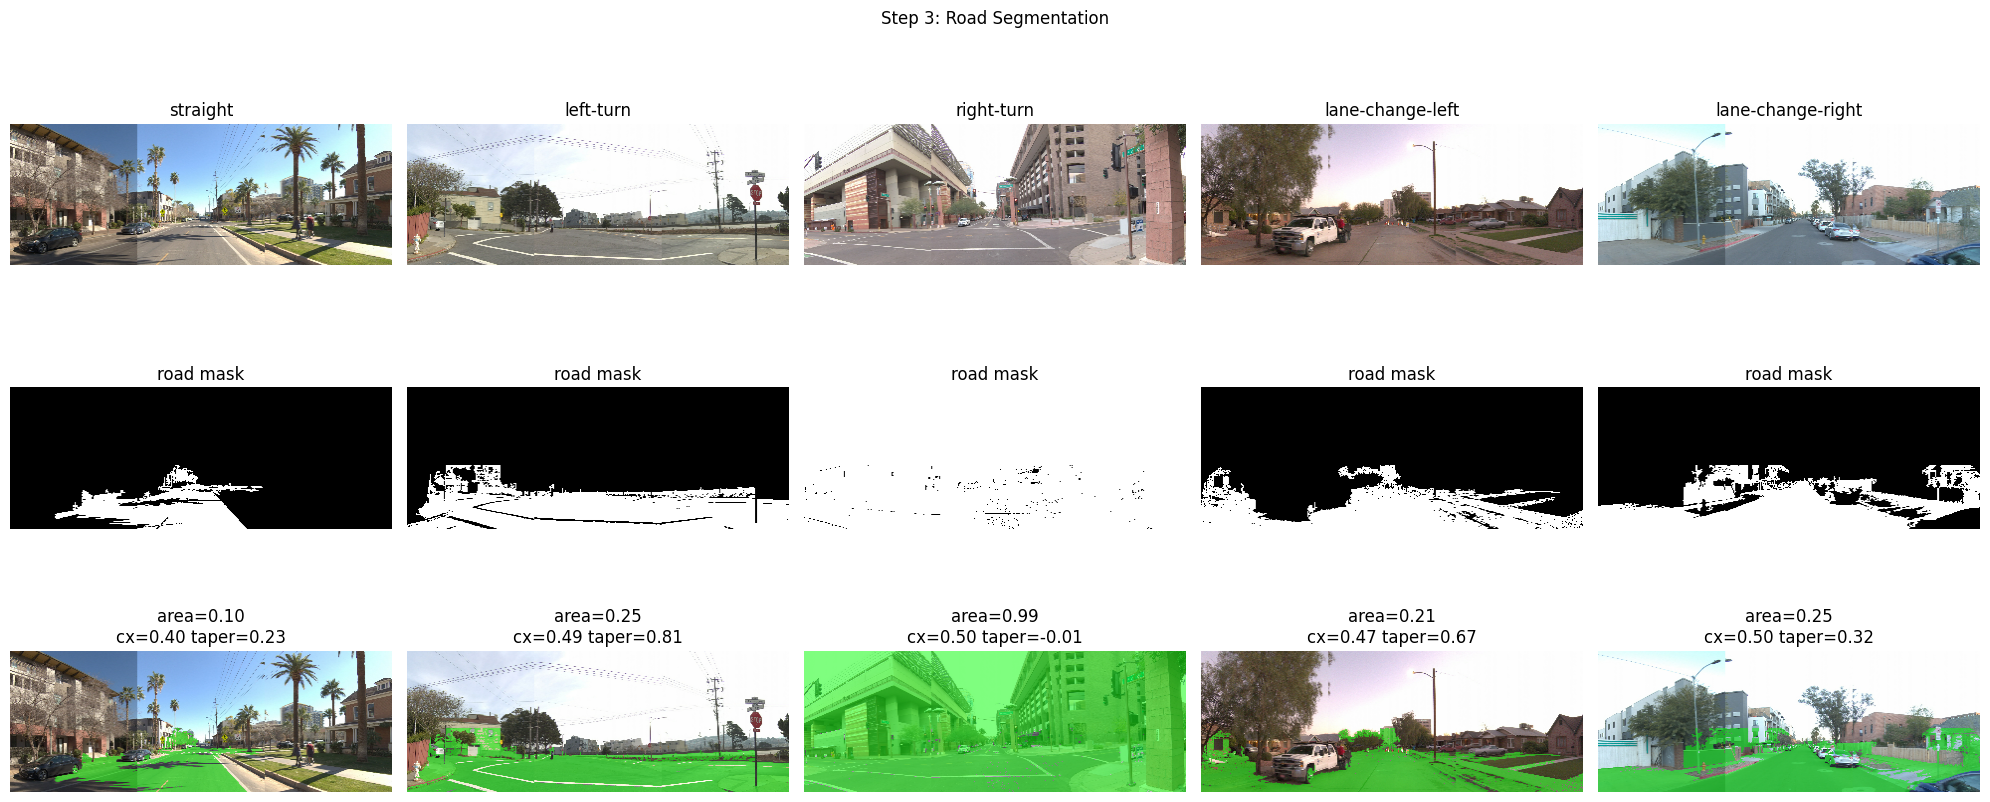

Road geometry features per class:
  straight: {'road_area_frac': 0.09734448356807512, 'road_centroid_x': np.float64(0.4048654939085657), 'road_width_bottom': np.float64(0.4609375), 'road_width_mid': np.float64(0.22916666666666666), 'road_taper': np.float64(0.23177083333333334)}
  left-turn: {'road_area_frac': 0.25300762910798125, 'road_centroid_x': np.float64(0.4866356190200058), 'road_width_bottom': np.float64(0.9427083333333334), 'road_width_mid': np.float64(0.1328125), 'road_taper': np.float64(0.8098958333333334)}
  right-turn: {'road_area_frac': 0.9933612089201878, 'road_centroid_x': np.float64(0.4988637840927273), 'road_width_bottom': np.float64(0.9713541666666666), 'road_width_mid': np.float64(0.984375), 'road_taper': np.float64(-0.01302083333333337)}
  lane-change-left: {'road_area_frac': 0.2050506161971831, 'road_centroid_x': np.float64(0.474156306830039), 'road_width_bottom': np.float64(0.7682291666666666), 'road_width_mid': np.float64(0.1015625), 'road_taper': np.float64(0.66

In [12]:
def get_robust_seed_color(hsv, H, W):
    """
    Sample multiple seed points at bottom of image,
    return the color and location of the point closest to the median HSV value.
    Robust to outliers like lane markings, crosswalks, shadows.
    """
    seed_points = [
        (W // 2, int(H * 0.95)),
        (W // 2, int(H * 0.85)),
        (int(W * 0.35), int(H * 0.92)),
        (int(W * 0.65), int(H * 0.92)),
        (int(W * 0.35), int(H * 0.82)),
        (int(W * 0.65), int(H * 0.82)),
    ]
    
    seed_colors = []
    valid_points = []
    for sx, sy in seed_points:
        patch = hsv[max(0, sy-5):sy+5, max(0, sx-10):sx+10]
        if patch.size > 0:
            seed_colors.append(np.mean(patch, axis=(0, 1)))
            valid_points.append((sx, sy))
    
    seed_colors = np.array(seed_colors)
    median_color = np.median(seed_colors, axis=0)
    distances = np.linalg.norm(seed_colors - median_color, axis=1)
    best_idx = np.argmin(distances)
    
    return seed_colors[best_idx].astype(np.uint8), valid_points[best_idx]


def segment_road(img, road_region_frac=0.55):
    """
    Step 3: Road segmentation via color-based region growing.
    
    Uses robust multi-point seed selection to avoid outlier seed colors
    (lane markings, crosswalks, shadows). Seeds from the bottom of the
    image where road surface is always present.
    
    Returns:
        road_mask: binary mask of segmented road region
        features: dict of road geometry features
    """
    H, W = img.shape[:2]
    
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    
    # robust seed selection
    seed_color, (seed_x, seed_y) = get_robust_seed_color(hsv, H, W)
    
    # color tolerance around seed
    tolerance = np.array([20, 60, 60])
    lower = np.clip(seed_color.astype(int) - tolerance, 0, 255).astype(np.uint8)
    upper = np.clip(seed_color.astype(int) + tolerance, 0, 255).astype(np.uint8)
    
    # mask pixels within color tolerance
    color_mask = cv2.inRange(hsv, lower, upper)
    
    # restrict to lower portion of image
    road_y_start = int(H * road_region_frac)
    color_mask[:road_y_start, :] = 0
    
    # flood fill from best seed point
    flood_mask = np.zeros((H + 2, W + 2), dtype=np.uint8)
    color_mask_copy = color_mask.copy()
    cv2.floodFill(color_mask_copy, flood_mask, (seed_x, seed_y), 255,
                  loDiff=(10, 10, 10), upDiff=(10, 10, 10))
    road_mask = (flood_mask[1:-1, 1:-1] * 255).astype(np.uint8)
    
    # compute road geometry features
    road_pixels = np.where(road_mask > 0)
    
    if len(road_pixels[0]) < 10:
        return road_mask, {
            'road_area_frac': 0.0,
            'road_centroid_x': 0.5,
            'road_width_bottom': 0.0,
            'road_width_mid': 0.0,
            'road_taper': 0.0,
        }
    
    total_pixels = H * W
    road_area_frac = len(road_pixels[0]) / total_pixels
    road_centroid_x = np.mean(road_pixels[1]) / W
    
    bottom_row = road_mask[int(H * 0.9), :]
    mid_row = road_mask[int(H * 0.7), :]
    road_width_bottom = np.sum(bottom_row > 0) / W
    road_width_mid = np.sum(mid_row > 0) / W
    road_taper = road_width_bottom - road_width_mid

    features = {
        'road_area_frac': road_area_frac,
        'road_centroid_x': road_centroid_x,
        'road_width_bottom': road_width_bottom,
        'road_width_mid': road_width_mid,
        'road_taper': road_taper,
    }
    
    return road_mask, features


# visualize
fig, axes = plt.subplots(3, len(CLASSES), figsize=(20, 9))

for i, cls in enumerate(CLASSES):
    img = examples[cls]
    road_mask, features = segment_road(img)
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(cls)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(road_mask, cmap='gray')
    axes[1, i].set_title('road mask')
    axes[1, i].axis('off')
    
    overlay = img.copy()
    overlay[road_mask > 0] = (overlay[road_mask > 0] * 0.5 +
                               np.array([0, 255, 0]) * 0.5).astype(np.uint8)
    axes[2, i].imshow(overlay)
    axes[2, i].set_title(f'area={features["road_area_frac"]:.2f}\n'
                          f'cx={features["road_centroid_x"]:.2f} '
                          f'taper={features["road_taper"]:.2f}')
    axes[2, i].axis('off')

plt.suptitle('Step 3: Road Segmentation')
plt.tight_layout()
plt.savefig('road_segmentation.png', dpi=150)
plt.show()

print('Road geometry features per class:')
for cls in CLASSES:
    _, features = segment_road(examples[cls])
    print(f'  {cls}: {features}')

In [13]:
# Full dataset feature extraction
# Runs HOG, YOLO (with position), and road segmentation across all 1,875 sequences
# Saves .npy files to FEATURES_DIR for PCA and classification

import time
all_hog = []
all_hsv = []
all_yolo = []
all_road = []
all_labels = []
all_seq_ids = []

start = time.time()

for i, (seq_id, entry) in enumerate(manifest.items()):
    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        rate = elapsed / (i + 1)
        remaining = rate * (len(manifest) - (i + 1))
        print(f'  {i+1}/{len(manifest)} — {remaining:.0f}s remaining...')

    data = np.load(os.path.join(TRAIN_DIR, entry['target_fname']), allow_pickle=True)
    img = np.array(data['_modality_data'].item()[Modality.CAMERAS])

    # simple feature 1: HOG
    hog_feat, _ = extract_hog(img)

    # simple feature 2: HSV histogram
    hsv_feat = extract_hsv_histogram(img)

    # complex feature: YOLO detections with position
    yolo_feat = extract_yolo_features(img, yolo_model)

    # simple feature 3: road geometry (vanishing point + segmentation)
    edges, lines, road_mask_bin = detect_edges_and_lines(img)
    vp, n_lines, _ = estimate_vanishing_point(lines, img.shape)
    _, road_features = segment_road(img)

    road_feat = np.array([
        vp[0],                              # vanishing point x (normalized)
        vp[1],                              # vanishing point y (normalized)
        n_lines,                            # number of detected lines
        road_features['road_area_frac'],
        road_features['road_centroid_x'],
        road_features['road_width_bottom'],
        road_features['road_width_mid'],
        road_features['road_taper'],
    ], dtype=np.float32)

    all_hog.append(hog_feat)
    all_hsv.append(hsv_feat)
    all_yolo.append(yolo_feat)
    all_road.append(road_feat)
    all_labels.append(entry['label'])
    all_seq_ids.append(seq_id)

# save to disk
np.save(os.path.join(FEATURES_DIR, 'hog.npy'), np.array(all_hog))
np.save(os.path.join(FEATURES_DIR, 'hsv.npy'), np.array(all_hsv))
np.save(os.path.join(FEATURES_DIR, 'yolo.npy'), np.array(all_yolo))
np.save(os.path.join(FEATURES_DIR, 'road.npy'), np.array(all_road))
np.save(os.path.join(FEATURES_DIR, 'labels.npy'), np.array(all_labels))
np.save(os.path.join(FEATURES_DIR, 'seq_ids.npy'), np.array(all_seq_ids))

elapsed = time.time() - start
print(f'\nDone in {elapsed:.0f}s')
print(f'HOG shape:  {np.array(all_hog).shape}')
print(f'HSV shape:  {np.array(all_hsv).shape}')
print(f'YOLO shape: {np.array(all_yolo).shape}')
print(f'Road shape: {np.array(all_road).shape}')
print(f'Labels:     {Counter(all_labels)}')

  100/2037 — 330s remaining...
  200/2037 — 310s remaining...
  300/2037 — 296s remaining...
  400/2037 — 283s remaining...
  500/2037 — 265s remaining...
  600/2037 — 245s remaining...
  700/2037 — 227s remaining...
  800/2037 — 209s remaining...
  900/2037 — 191s remaining...
  1000/2037 — 174s remaining...
  1100/2037 — 157s remaining...
  1200/2037 — 142s remaining...
  1300/2037 — 127s remaining...
  1400/2037 — 114s remaining...
  1500/2037 — 99s remaining...
  1600/2037 — 84s remaining...
  1700/2037 — 67s remaining...
  1800/2037 — 49s remaining...
  1900/2037 — 29s remaining...
  2000/2037 — 8s remaining...

Done in 447s
HOG shape:  (2037, 5796)
HSV shape:  (2037, 34)
YOLO shape: (2037, 32)
Road shape: (2037, 8)
Labels:     Counter({'straight': 745, 'right-turn': 467, 'left-turn': 392, 'lane-change-right': 222, 'lane-change-left': 200, 'stationary': 11})


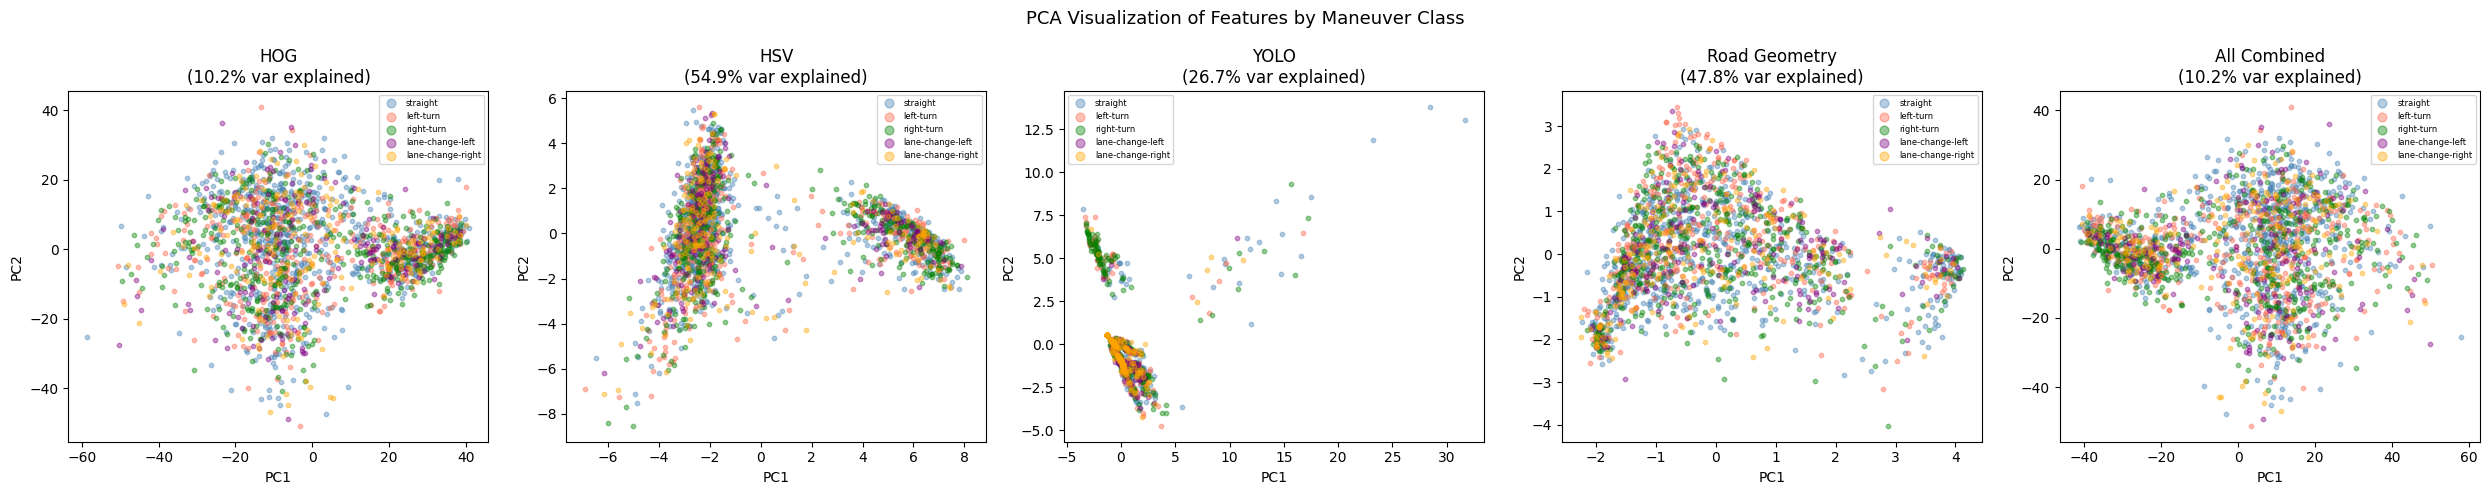

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# load saved features
hog_feats = np.load(os.path.join(FEATURES_DIR, 'hog.npy'))
hsv_feats = np.load(os.path.join(FEATURES_DIR, 'hsv.npy'))
yolo_feats = np.load(os.path.join(FEATURES_DIR, 'yolo.npy'))
road_feats = np.load(os.path.join(FEATURES_DIR, 'road.npy'))
labels = np.load(os.path.join(FEATURES_DIR, 'labels.npy'))

feature_sets = {
    'HOG': hog_feats,
    'HSV': hsv_feats,
    'YOLO': yolo_feats,
    'Road Geometry': road_feats,
    'All Combined': np.concatenate([hog_feats, hsv_feats, yolo_feats, road_feats], axis=1),
}

colors = {
    'straight': 'steelblue',
    'left-turn': 'tomato',
    'right-turn': 'green',
    'lane-change-left': 'purple',
    'lane-change-right': 'orange',
}

fig, axes = plt.subplots(1, len(feature_sets), figsize=(25, 5))

for ax, (name, feats) in zip(axes, feature_sets.items()):
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats)
    pca = PCA(n_components=2)
    projected = pca.fit_transform(feats_scaled)
    var_explained = pca.explained_variance_ratio_.sum() * 100

    for cls in CLASSES:
        mask = labels == cls
        ax.scatter(projected[mask, 0], projected[mask, 1],
                   c=colors[cls], label=cls, alpha=0.4, s=10)
    ax.set_title(f'{name}\n({var_explained:.1f}% var explained)')
    ax.legend(fontsize=6, markerscale=2)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('PCA Visualization of Features by Maneuver Class', fontsize=13)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150)
plt.show()

In [15]:
_arrays_exist = all(
    os.path.exists(os.path.join(FEATURES_DIR, f))
    for f in ['hog.npy', 'yolo.npy', 'road.npy', 'labels.npy']
)

if _arrays_exist:
    hog_features  = np.load(os.path.join(FEATURES_DIR, 'hog.npy'))
    yolo_features = np.load(os.path.join(FEATURES_DIR, 'yolo.npy'))
    road_features = np.load(os.path.join(FEATURES_DIR, 'road.npy'))
    labels        = np.load(os.path.join(FEATURES_DIR, 'labels.npy'), allow_pickle=True)
    print('Loaded features:')
    print(f'  HOG:   {hog_features.shape}')
    print(f'  YOLO:  {yolo_features.shape}')
    print(f'  Road:  {road_features.shape}')
    print(f'  Labels: {Counter(labels)}')
    print('\nArrays loaded -- skip the extraction loop below.')
else:
    print('Feature arrays not found -- run the extraction loop below, then re-run this cell.')

Loaded features:
  HOG:   (2037, 5796)
  YOLO:  (2037, 32)
  Road:  (2037, 8)
  Labels: Counter({np.str_('straight'): 745, np.str_('right-turn'): 467, np.str_('left-turn'): 392, np.str_('lane-change-right'): 222, np.str_('lane-change-left'): 200, np.str_('stationary'): 11})

Arrays loaded -- skip the extraction loop below.
